In [7]:
#2021245151 정용의

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast  # AMP 추가 (혼합 정밀도 학습을 위해 사용)
import os
import time
import matplotlib.pyplot as plt


# **WideBasic 클래스 정의**

In [8]:
# Residual 블록을 확장하여 WideResNet에 맞는 블록으로 만듦
class WideBasic(nn.Module):
    def __init__(self, in_planes, planes, dropout_rate, stride=1):
        # 이 블록에서 필요한 모든 레이어들을 초기화함
        super(WideBasic, self).__init__()
        # 첫 번째 Batch Normalization 레이어
        self.bn1 = nn.BatchNorm2d(in_planes)
        # 첫 번째 Convolution 레이어 (필터 개수는 'planes', 커널 크기 3x3, 패딩 1로 설정)
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, padding=1, bias=True)
        # 드롭아웃 레이어 - dropout_rate에 따라 일정 비율의 뉴런을 비활성화하여 과적합 방지
        self.dropout = nn.Dropout(p=dropout_rate)
        # 두 번째 Batch Normalization 레이어
        self.bn2 = nn.BatchNorm2d(planes)
        # 두 번째 Convolution 레이어 (stride는 인자로 받음)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=True)

        # Residual 연결 설정 - 입력과 출력의 크기가 다를 때 크기를 맞추기 위한 Convolution 사용
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            # Shortcut 경로에서 stride나 채널 수가 맞지 않으면 크기 조정을 위해 1x1 Convolution 사용
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride, bias=True),
            )

    def forward(self, x):
        # 입력을 BatchNorm, ReLU, Convolution, Dropout을 통해 처리
        out = self.dropout(self.conv1(F.relu(self.bn1(x))))
        # 그 다음 두 번째 BatchNorm, ReLU, Convolution을 적용
        out = self.conv2(F.relu(self.bn2(out)))
        # 입력 x와 현재 처리된 결과를 더함 (Residual 연결)
        out += self.shortcut(x)
        return out  # Residual 합이 적용된 값을 반환

WideBasic 블록은 ResNet의 핵심 구성요소인 Residual 블록을 확장한 형태로, 네트워크의 기본 구성 단위이며 해당 블록은 두개의 Convolution 레이어와 Batch Normalization, Dropout을 포함하며, 입력 값과 출력 값 간에 'shortcut' 연결을 통해 Residual을 추가하는 구조로 되어 있다. 이 구조는 딥러닝에서 네트워크 깊이가 깊어질 때 발생할 수 있는 기울기 소실 문제를 해결하는데 도와주는 중요한 요소이다.

# **Wide_ResNet 모델 정의**

In [9]:
class WideResNet(nn.Module):
    def __init__(self, depth, widen_factor, dropout_rate, num_classes):
        # 네트워크의 전체 구조를 정의하는 부분
        super(WideResNet, self).__init__()
        self.in_planes = 16  # 초기 입력 채널을 16으로 설정 (이 값은 WideResNet 구조에 맞게 고정됨)

        # depth는 6n+4 형식이어야 함. 이를 검증하는 assert문
        assert ((depth-4)%6 == 0), 'Wide-ResNet depth should be 6n+4'
        # depth에서 n값을 계산 (depth에 따라 블록의 개수가 결정됨)
        n = (depth-4)//6
        # 네트워크의 폭을 조정하기 위한 widen_factor
        k = widen_factor
        # 각 단계의 채널 수 설정 (16, 16*k, 32*k, 64*k로 단계별로 증가)
        nStages = [16, 16*k, 32*k, 64*k]

        # 첫 번째 Convolution 레이어, 입력 채널은 3(RGB 이미지), 출력 채널은 nStages[0]으로 설정
        self.conv1 = nn.Conv2d(3, nStages[0], kernel_size=3, stride=1, padding=1, bias=True)
        # WideBasic 블록을 쌓아가는 네트워크의 각 레이어 설정
        self.layer1 = self._wide_layer(WideBasic, nStages[1], n, dropout_rate, stride=1)
        self.layer2 = self._wide_layer(WideBasic, nStages[2], n, dropout_rate, stride=2)
        self.layer3 = self._wide_layer(WideBasic, nStages[3], n, dropout_rate, stride=2)
        # 마지막 BatchNorm 레이어
        self.bn1 = nn.BatchNorm2d(nStages[3], momentum=0.9)
        # 마지막 Fully Connected Layer로 CIFAR-10 분류를 위해 클래스 개수는 10개로 설정
        self.linear = nn.Linear(nStages[3], num_classes)

    # WideBasic 블록을 여러 개 쌓는 함수
    def _wide_layer(self, block, planes, num_blocks, dropout_rate, stride):
        strides = [stride] + [1]*(num_blocks-1)  # 첫 블록은 stride가 다를 수 있으나 나머지는 stride 1로 고정
        layers = []
        for stride in strides:
            # 각 블록을 추가하며 입력 채널은 이전 출력 채널과 동일하게 맞춤
            layers.append(block(self.in_planes, planes, dropout_rate, stride))
            self.in_planes = planes  # 현재 출력 채널을 다음 입력 채널로 업데이트
        return nn.Sequential(*layers)  # 레이어들을 순차적으로 쌓음

    def forward(self, x):
        # 처음 Conv 레이어와 각 레이어를 거치면서 출력 계산
        out = self.conv1(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.relu(self.bn1(out))  # 마지막 BatchNorm 이후 ReLU 적용
        out = F.avg_pool2d(out, 8)  # 8x8 크기의 Average Pooling 적용
        out = out.view(out.size(0), -1)  # Flatten 처리
        out = self.linear(out)  # 최종적으로 Fully Connected Layer를 거침
        return out  # 모델의 최종 출력 반환


WideResNet은 네트워크의 전체 구조를 정의하는 클래스이고 여기서 depth는 네트워크의 깊이를, widen_factor는 네트워크의 폭을 조정하는 인자. 이 모델은 3개의 레이어(WideBasic 블록으로 구성)로 구성되어 있으며, 각 레이어는 점진적으로 채널 수를 늘려가면서 특징을 추출하는 동작을 수행한다. 마지막에는 CIFAR-10 데이터셋의 10개의 클래스를 분류하기 위한 Fully Connected 레이어가 추가됨.

# **데이터셋 로드 및 전처리 함수**

In [10]:
def get_data_loaders(batch_size=128):
    # 학습 데이터 전처리 - 데이터 증강을 위해 랜덤 자르기와 수평 뒤집기 적용, 그리고 정규화
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),  # CIFAR-10 평균값과 표준편차로 정규화
    ])

    # 테스트 데이터 전처리 - 정규화만 적용 (데이터 증강 없이 원본 그대로 테스트)
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    # 학습 데이터셋을 CIFAR-10에서 불러오고 DataLoader로 패키징
    trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)

    # 테스트 데이터셋을 CIFAR-10에서 불러오고 DataLoader로 패키징
    testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
    testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=8, pin_memory=True)

    return trainloader, testloader  # 학습용과 테스트용 DataLoader 반환


이 함수는 CIFAR-10 데이터셋을 불러와 학습용(train)과 테스트용(test) 데이터셋을 준비하는 함수! 데이터셋에 대해 몇 가지 전처리(데이터 증강: RandomCrop, RandomHorizontalFlip, 그리고 정규화)동작을 수행함. 이 과정은 학습 시 모델의 일반화 성능을 높이는 데 도움을 줄 수 있다. DataLoader를 사용하여 데이터를 배치 단위로 불러올 수 있도록 설정.

# **학습 및 평가 함수 정의**

In [11]:
# 학습 함수 정의
def train(net, trainloader, optimizer, criterion, scaler, device):
    net.train() # 모델을 학습 모드로 전환
    train_loss = 0 # 학습 손실을 저장할 변수
    correct = 0 # 맞춘 샘플 수
    total = 0 # 전체 샘플 수

    # 학습 데이터를 배치 단위로 불러와 학습을 진행
    for batch_idx, (inputs, targets) in enumerate(trainloader):
        inputs, targets = inputs.to(device), targets.to(device) # 데이터를 GPU로 이동

        optimizer.zero_grad() # 이전 배치의 그래디언트를 초기화

        # 혼합 정밀도 학습 적용
        with autocast(): # 입력 데이터를 반정밀도로 처리
            outputs = net(inputs) # 네트워크에 입력을 주어 출력을 계산
            loss = criterion(outputs, targets) # 손실 함수로 출력을 비교하여 손실 계산

        # 역전파 및 가중치 업데이트
        scaler.scale(loss).backward() # 손실을 역전파
        scaler.step(optimizer) # 옵티마이저로 가중치 업데이트
        scaler.update() # 스케일러 업데이트

        # 손실을 누적하고, 정확도를 계산하기 위한 변수 업데이트
        train_loss += loss.item() # 배치 손실을 누적
        _, predicted = outputs.max(1) # 최대 확률을 가진 클래스를 예측 값으로 선택
        total += targets.size(0) # 총 샘플 수 누적
        correct += predicted.eq(targets).sum().item() # 예측이 맞은 샘플 수 누적

    # 평균 손실과 정확도를 반환
    return train_loss / len(trainloader), 100. * correct / total

# 테스트 함수 정의
def test(net, testloader, criterion, device):
    net.eval() # 모델을 평가 모드로 전환
    test_loss = 0 # 테스트 손실을 저장할 변수
    correct = 0 # 맞춘 샘플 수
    total = 0 # 전체 샘플 수

    # 그래디언트를 계산하지 않고, 테스트 데이터를 모델에 입력하여 평가
    with torch.no_grad(): # 테스트에서는 그래디언트가 필요 없으므로 no_grad 블록을 사용
        for batch_idx, (inputs, targets) in enumerate(testloader):
            inputs, targets = inputs.to(device), targets.to(device) # 데이터를 GPU로 이동

            outputs = net(inputs) # 네트워크에 입력을 주어 출력을 계산
            loss = criterion(outputs, targets) # 손실 함수로 출력을 비교하여 손실 계산

            # 손실과 정확도를 누적
            test_loss += loss.item() # 배치 손실을 누적
            _, predicted = outputs.max(1) # 예측 값을 선택
            total += targets.size(0) # 총 샘플 수 누적
            correct += predicted.eq(targets).sum().item() # 맞춘 샘플 수 누적

    # 평균 손실과 정확도를 반환
    return test_loss / len(testloader), 100. * correct / total


학습 함수는 모델을 학습 모드로 전환한 후 각 배치별로 데이터를 불러와 모델에 입력하는데 이 과정에서 autocast를 사용해 혼합 정밀도 학습(AMP)을 적용하여 학습 속도를 높인다.. 손실 함수(여기서는 CrossEntropyLoss)를 계산하고, 역전파(backpropagation)를 통해 그래디언트를 계산한 후, 옵티마이저로 모델의 파라미터를 업데이트하고 각 배치에서의 손실 값과 예측이 맞은 샘플 수를 기록해 학습 정확도를 측정한다. 테스트 함수는 학습된 모델을 평가하는 역할을 수행한다. 테스트 데이터를 모델에 입력하고, 예측 결과와 실제 값을 비교해 손실과 정확도를 계산하는데 이때 학습과 달리, 테스트에서는 파라미터 업데이트나 그래디언트 계산이 없기 때문에 torch.no_grad()를 사용해 그래디언트 계산을 비활성화한다.

# **메인 함수 및 학습 실행**

메인 함수는 전체 모델 학습 과정을 담당하는데. 먼저, 사용할 장치를 GPU나 CPU로 설정하고, 모델을 초기화한 후 DataLoader로 CIFAR-10 데이터를 불러온다. 그 후, 각 에포크에서 학습과 평가를 수행하고, 학습 손실, 테스트 손실, 정확도를 기록합니다. 학습 중 테스트 정확도가 최고 기록을 갱신할 때마다 모델을 저장하며, 마지막에 학습이 끝나면 학습 및 테스트 손실과 정확도 변화를 시각화하여 그래프로 출력하는 동작을 수행한다.

==> 모델 초기화 및 설정
Files already downloaded and verified
Files already downloaded and verified

Epoch 1/20: 

<ipython-input-12-51819223a7a2>:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() # 혼합 정밀도 학습을 위한 스케일러 정의
<ipython-input-11-9f6990b00edc>:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 입력 데이터를 반정밀도로 처리


Train Loss [1.6244] / Test Loss [1.5726], Test Accuracy [49.68%], Run Time [159.33 sec]
Saving.. Test Accuracy: 49.680%

Epoch 2/20: Train Loss [1.1109] / Test Loss [1.3873], Test Accuracy [56.43%], Run Time [158.95 sec]
Saving.. Test Accuracy: 56.430%

Epoch 3/20: Train Loss [0.9188] / Test Loss [1.4618], Test Accuracy [58.49%], Run Time [158.82 sec]
Saving.. Test Accuracy: 58.490%

Epoch 4/20: Train Loss [0.7921] / Test Loss [1.6840], Test Accuracy [53.84%], Run Time [158.49 sec]

Epoch 5/20: Train Loss [0.6777] / Test Loss [1.1357], Test Accuracy [67.53%], Run Time [158.72 sec]
Saving.. Test Accuracy: 67.530%

Epoch 6/20: Train Loss [0.6043] / Test Loss [1.1182], Test Accuracy [68.97%], Run Time [158.06 sec]
Saving.. Test Accuracy: 68.970%

Epoch 7/20: Train Loss [0.5414] / Test Loss [0.6678], Test Accuracy [78.86%], Run Time [158.28 sec]
Saving.. Test Accuracy: 78.860%

Epoch 8/20: Train Loss [0.4976] / Test Loss [1.1812], Test Accuracy [69.08%], Run Time [158.04 sec]

Epoch 9/20: 

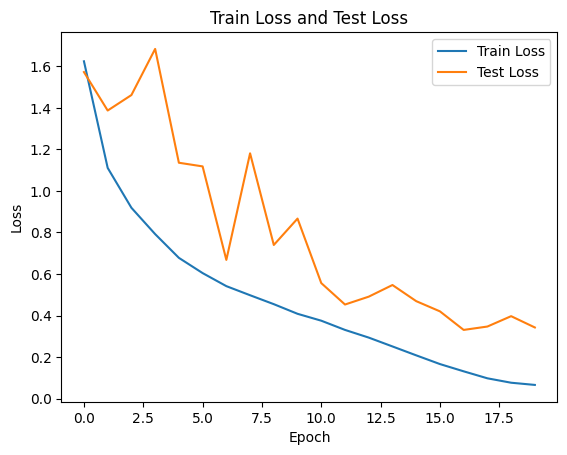

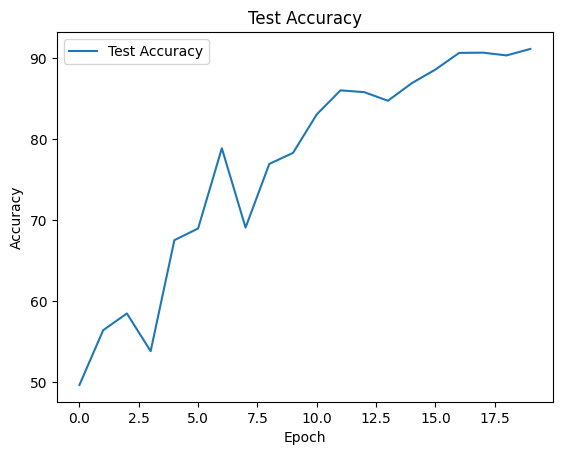

In [12]:
# 메인 함수 정의
def main():
    device = 'cuda' if torch.cuda.is_available() else 'cpu' # GPU가 사용 가능하면 GPU 사용, 그렇지 않으면 CPU 사용
    best_acc = 0 # 최고 정확도를 기록하기 위한 변수 초기화
    start_epoch = 0
    num_epochs = 20 # 학습할 에포크 수 설정
    batch_size = 128 # 배치 크기 설정

    # 학습 로그를 저장할 딕셔너리
    train_log = {
        'train_loss': [], # 학습 손실 기록
        'test_loss': [], # 테스트 손실 기록
        'acc': [] # 정확도 기록
    }

    # 모델 초기화 및 설정
    print('==> 모델 초기화 및 설정')
    net = WideResNet(depth=28, widen_factor=10, dropout_rate=0.3, num_classes=10)
    net = net.to(device)

    if device == 'cuda': # GPU가 사용 가능하면 추가 최적화 설정 적용
        net = torch.nn.DataParallel(net) # 멀티 GPU 사용을 위한 DataParallel 적용
        cudnn.benchmark = True # GPU 최적화를 위한 설정

    # 데이터셋 로드 및 데이터 로더 준비
    trainloader, testloader = get_data_loaders(batch_size)

    # 손실 함수와 옵티마이저 정의
    criterion = nn.CrossEntropyLoss() # CrossEntropyLoss 사용 (분류 문제에서 사용되는 일반적인 손실 함수)
    optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4) # SGD 옵티마이저
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs) # 학습률 스케줄러로 CosineAnnealing 사용
    scaler = GradScaler() # 혼합 정밀도 학습을 위한 스케일러 정의

    # 각 에포크마다 학습 및 평가 수행
    for epoch in range(start_epoch, start_epoch + num_epochs):
        epoch_start_time = time.time() # 에포크 시작 시간 기록

        # 학습 단계 실행
        print(f'\nEpoch {epoch+1}/{num_epochs}: ', end='')
        train_loss, train_acc = train(net, trainloader, optimizer, criterion, scaler, device)
        test_loss, test_acc = test(net, testloader, criterion, device)

        epoch_end_time = time.time() # 에포크 끝 시간 기록
        run_time = epoch_end_time - epoch_start_time # 에포크 실행 시간 계산

        # 학습 및 테스트 손실과 정확도 출력
        print(f'Train Loss [{train_loss:.4f}] / Test Loss [{test_loss:.4f}], Test Accuracy [{test_acc:.2f}%], Run Time [{run_time:.2f} sec]')

        scheduler.step()  # 학습률 스케줄러 업데이트

        # 학습 로그에 손실과 정확도 저장
        train_log['train_loss'].append(train_loss)
        train_log['test_loss'].append(test_loss)
        train_log['acc'].append(test_acc)

        # 현재 에포크의 테스트 정확도가 최고 기록을 갱신했을 경우 모델 저장
        if test_acc > best_acc:
            print(f'Saving.. Test Accuracy: {test_acc:.3f}%')
            state = {
                'net': net.state_dict(), # 네트워크의 가중치 저장
                'acc': test_acc, # 테스트 정확도 저장
                'epoch': epoch, # 현재 에포크 번호 저장
            }
            if not os.path.isdir('checkpoint'):  # 체크포인트 폴더가 없으면 생성
                os.mkdir('checkpoint')
            torch.save(state, './checkpoint/wide-resnet28x10.pth')  # 모델 저장
            best_acc = test_acc  # 최고 정확도 갱신

    print(f'Best Accuracy: {best_acc:.3f}%') # 최고 정확도 출력

    plt.figure()
    plt.title('Train Loss and Test Loss')
    plt.xlabel('Epoch')  # X축 레이블
    plt.ylabel('Loss')  # Y축 레이블
    plt.plot(train_log['train_loss'], label='Train Loss')  # 학습 손실 그래프
    plt.plot(train_log['test_loss'], label='Test Loss')  # 테스트 손실 그래프
    plt.legend()  # 범례 추가
    plt.show()

    plt.figure()
    plt.title('Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.plot(train_log['acc'], label='Test Accuracy')
    plt.legend()
    plt.show()

if __name__ == '__main__':
    main()
